# Fez Network: Syndrome and Ground Truth Data Generation

This notebook generates both syndrome measurements (multi-hop paths) and ground truth error rates (single-hop edges) for the quantum network.

**Outputs:**
- `measurements.pkl` - Syndrome measurements for all paths
- `graph.pkl` - Network topology graph
- `ground_truth.pkl` - Individual Pauli error rates (px, py, pz) for each edge

In [1]:
from qiskit import QuantumCircuit, ClassicalRegister, transpile
import rustworkx
from rustworkx.visualization import graphviz_draw

import sys
import numpy as np
from pathlib import Path
from datetime import datetime
import pickle
import networkx as nx
from typing import List, Dict, Tuple

# Add parent directory to path for network_emulation package
sys.path.insert(0, '../..')

# Import from network_emulation package
from network_emulation import (
    # Node utilities
    Node, NODE_NAMES, NUM_NODES, INITIAL_STATES, STATE_LABELS,
    CONNECTION_TUPLES, get_node_name, route_name, get_node_id,
    # Config loading
    load_nodes_config, load_routes_config,
    # Circuit building
    build_swapping_circuit, build_multihop_swapping_circuit,
    # Experiment execution
    initialize_backend, run_provided_circuit, execute_transpiled_circuit,
    # Visualization & export
    plot_syndrome_matrix, plot_all_states_comparison, plot_state_averages_bar,
    print_matrix_summary, print_full_comparison, save_results_to_json
)

## Configuration

In [2]:
# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================

USE_REAL_HARDWARE = False  # Toggle between real hardware and simulator

# Experiment parameters
NUM_SHOTS = 4096           # Number of shots per circuit execution
OPTIMIZATION_LEVEL = 1     # Transpiler optimization (0 = no optimization)
MIN_NODES = 3               # Minimum number of nodes (hops + 1) for path finding
MAX_NODES = 4               # Maximum number of nodes (hops + 1) for path finding

# Ground Truth data generation parameters
ALL_QUBITS = False  # Use True all logical qubits for encoding and measurement
# ============================================================
# Configuration file paths
CONFIG_DIR = Path('../../configs')
CONFIG_NUM = '2'  # Configuration number to use
NODES_FILE = CONFIG_DIR / f'config_{CONFIG_NUM}_nodes.json'
ROUTES_FILE = CONFIG_DIR / f'config_{CONFIG_NUM}_routes.json'

# Input graph file
GRAPH_INPUT_FILE = Path('../../pickle_files/2x3_grid_mod_network_graph.pkl')

# Output directory (will be created with timestamp)
OUTPUT_BASE_DIR = Path('../../pickle_files')

print("="*60)
print("EXPERIMENT CONFIGURATION")
print("="*60)
print(f"Hardware mode:      {'REAL IBM HARDWARE' if USE_REAL_HARDWARE else 'FakeFez SIMULATOR'}")
print(f"Shots per circuit:  {NUM_SHOTS}")
print(f"Optimization level: {OPTIMIZATION_LEVEL}")
print(f"Min hops:           {MIN_NODES - 1}")
print(f"Max hops:           {MAX_NODES - 1}")
print("\nConfig files:")
print(f"  Nodes:  {NODES_FILE} (exists: {NODES_FILE.exists()})")
print(f"  Routes: {ROUTES_FILE} (exists: {ROUTES_FILE.exists()})")
print(f"  Graph:  {GRAPH_INPUT_FILE} (exists: {GRAPH_INPUT_FILE.exists()})")

EXPERIMENT CONFIGURATION
Hardware mode:      FakeFez SIMULATOR
Shots per circuit:  4096
Optimization level: 1
Min hops:           2
Max hops:           3

Config files:
  Nodes:  ../../configs/config_2_nodes.json (exists: True)
  Routes: ../../configs/config_2_routes.json (exists: True)
  Graph:  ../../pickle_files/2x3_grid_mod_network_graph.pkl (exists: True)


In [3]:
# ============================================================
# LOAD CONFIGURATIONS
# ============================================================

# Load node and route configurations from JSON files
NODES = load_nodes_config(NODES_FILE)
TRANSPORT_ROUTES = load_routes_config(ROUTES_FILE)

print("="*60)
print("LOADED CONFIGURATIONS")
print("="*60)
print(f"\nNodes ({len(NODES)} total):")
for node_id, qubits in NODES.items():
    print(f"  Node {get_node_name(node_id)}: data={qubits['data']}, "
          f"encoding={qubits['encoding']}, ancilla={qubits['ancilla']}")

print(f"\nRoutes ({len(TRANSPORT_ROUTES)} total)")
print(f"Connection pairs: {len(CONNECTION_TUPLES)}")

# ============================================================
# INITIALIZE BACKEND
# ============================================================

backend, simulator, coupling_map, IS_REAL_HARDWARE = initialize_backend(
    USE_REAL_HARDWARE,
    secrets_path='../../secrets/personal-apikey.json',
    simulation_method="matrix_product_state"
)

LOADED CONFIGURATIONS

Nodes (6 total):
  Node A: data=[96], encoding=[83, 103], ancilla=[84, 104]
  Node B: data=[97], encoding=[87, 107], ancilla=[88, 108]
  Node C: data=[98], encoding=[91, 111], ancilla=[92, 112]
  Node D: data=[116], encoding=[101, 121], ancilla=[102, 122]
  Node E: data=[117], encoding=[105, 125], ancilla=[106, 126]
  Node F: data=[118], encoding=[109, 129], ancilla=[110, 130]

Routes (30 total)
Connection pairs: 30
Loaded SIMULATOR backend: fake_fez
  Qubits: 156
  Simulation method: matrix_product_state


## Load Network Graph

In [4]:
# ============================================================
# LOAD NETWORK GRAPH FROM PICKLE FILE
# ============================================================

with open(GRAPH_INPUT_FILE, 'rb') as f:
    loaded_graph = pickle.load(f)

print(f"Loaded graph type: {type(loaded_graph)}")
print(f"Nodes: {loaded_graph.nodes() if hasattr(loaded_graph, 'nodes') else 'N/A'}")
print(f"Edges: {list(loaded_graph.edges())}")

# Get single-hop edges for ground truth measurement
single_hop_edges = list(loaded_graph.edges())
print(f"\nSingle-hop edges for ground truth: {single_hop_edges}")

Loaded graph type: <class 'networkx.classes.graph.Graph'>
Nodes: [0, 1, 2, 3, 4, 5]
Edges: [(0, 1), (0, 3), (0, 4), (1, 2), (1, 4), (1, 5), (2, 5), (3, 4), (4, 5)]

Single-hop edges for ground truth: [(0, 1), (0, 3), (0, 4), (1, 2), (1, 4), (1, 5), (2, 5), (3, 4), (4, 5)]


Built rustworkx graph with 6 nodes and 9 edges


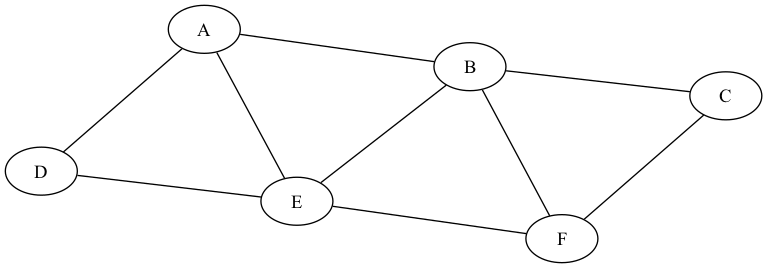

In [5]:
# ============================================================
# BUILD RUSTWORKX GRAPH FOR PATH FINDING
# ============================================================

def node_attr(node):
    return {'label': node[1]}

network_graph = rustworkx.PyGraph()
graph_node_indices = {}

for node in NODE_NAMES.items():
    id = network_graph.add_node(node)
    graph_node_indices.update({node[1]: id})

# Add edges from the loaded graph
for edge in single_hop_edges:
    u, v = edge
    # Map node IDs to rustworkx indices
    network_graph.add_edge(u, v, None)

print(f"Built rustworkx graph with {len(network_graph.node_indices())} nodes and {len(network_graph.edge_list())} edges")
graphviz_draw(network_graph, node_attr_fn=node_attr, edge_attr_fn=None, method='sfdp')

In [6]:
# ============================================================
# FIND ALL PATHS UP TO MAX_HOPS
# ============================================================

PATH_DICT = {}
total_paths = 0

for node_id in network_graph.node_indices():
    node = network_graph.get_node_data(node_id)
    paths = {id: rustworkx.all_simple_paths(network_graph, node_id, to=id, min_depth=MIN_NODES, cutoff=MAX_NODES) 
             for id in network_graph.node_indices()}
    paths.pop(node_id)
    
    for dest_id, path_list in paths.items():
        total_paths += len(path_list)
        if path_list:
            print(f"From node {node_id} to node {dest_id}: {len(path_list)} paths")
            print(f"  Paths: {path_list}")
    
    PATH_DICT.update({node_id: paths})

print(f"\nTotal paths found: {total_paths}")

From node 0 to node 1: 3 paths
  Paths: [[0, 4, 5, 1], [0, 4, 1], [0, 3, 4, 1]]
From node 0 to node 2: 4 paths
  Paths: [[0, 4, 5, 2], [0, 4, 1, 2], [0, 1, 5, 2], [0, 1, 2]]
From node 0 to node 3: 2 paths
  Paths: [[0, 4, 3], [0, 1, 4, 3]]
From node 0 to node 4: 3 paths
  Paths: [[0, 3, 4], [0, 1, 5, 4], [0, 1, 4]]
From node 0 to node 5: 6 paths
  Paths: [[0, 4, 5], [0, 4, 1, 5], [0, 3, 4, 5], [0, 1, 5], [0, 1, 4, 5], [0, 1, 2, 5]]
From node 1 to node 0: 3 paths
  Paths: [[1, 5, 4, 0], [1, 4, 3, 0], [1, 4, 0]]
From node 1 to node 2: 2 paths
  Paths: [[1, 5, 2], [1, 4, 5, 2]]
From node 1 to node 3: 5 paths
  Paths: [[1, 5, 4, 3], [1, 4, 3], [1, 4, 0, 3], [1, 0, 4, 3], [1, 0, 3]]
From node 1 to node 4: 4 paths
  Paths: [[1, 5, 4], [1, 2, 5, 4], [1, 0, 4], [1, 0, 3, 4]]
From node 1 to node 5: 3 paths
  Paths: [[1, 4, 5], [1, 2, 5], [1, 0, 4, 5]]
From node 2 to node 0: 4 paths
  Paths: [[2, 5, 4, 0], [2, 5, 1, 0], [2, 1, 4, 0], [2, 1, 0]]
From node 2 to node 1: 2 paths
  Paths: [[2, 5, 4, 

## Helper Functions and Classes

In [7]:
class TimeAwareMeasurement:
    """Data class for syndrome measurements with timing information."""
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513'):
        """
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A numpy array of syndrome counts.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '313_X', '313_Z', '513'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type

In [8]:
def build_ground_truth_circuit(
    node_path: List[int],
    initial_state: str,
    nodes: Dict[int, dict],
    routes: Dict[Tuple[int, int], dict],
    num_qubits: int,
    measurement_basis: str = "Z",
    all_qubits: bool = False
) -> QuantumCircuit:
    """
    Build a circuit for ground truth measurement in X, Y, or Z basis.
    
    Each basis detects two types of Pauli errors:
    - Z-basis: Detects X and Y errors (e_z = px + py)
    - X-basis: Detects Y and Z errors (e_x = py + pz)
    - Y-basis: Detects X and Z errors (e_y = px + pz)
    
    Args:
        node_path: Ordered list of node IDs describing the path (>=2 nodes).
        initial_state: "0" or "1"
        nodes: Dict mapping node_id -> {"data": int, "encoding": [int,int], ...}
        routes: Dict mapping (src_node,dst_node) -> {"movements": [[path1],[path2],[path3]]}
        num_qubits: Total number of physical qubits in the backend.
        measurement_basis: "X", "Y", or "Z"
    
    Returns:
        QuantumCircuit with measurement register
    """
    if len(node_path) < 2:
        raise ValueError("node_path must contain at least 2 nodes")
    if initial_state not in ("0", "1"):
        raise ValueError("initial_state must be '0' or '1'")
    if measurement_basis not in ("X", "Z", "Y"):
        raise ValueError("measurement_basis must be 'X', 'Y', or 'Z'")

    start_node = node_path[0]
    final_node = node_path[-1]
    circuit = QuantumCircuit(num_qubits)

    src_data = nodes[start_node]["data"]
    if all_qubits:
        src_encoding = nodes[start_node]["encoding"]

    dst_data = nodes[final_node]["data"]

    if all_qubits:
        dst_encoding = nodes[final_node]["encoding"]

    # Prepare initial state
    if initial_state == "1":
        circuit.x(src_data[0])
    
    # Perform encoding if required
    if all_qubits:
        for qubit in src_encoding:
            circuit.cx(src_data[0], qubit)
    
    circuit.barrier(label=f"Init: |{initial_state}⟩ @ {get_node_name(start_node)}")

    # Rotate to measurement basis BEFORE transport
    circuit.barrier(label=f"Rotate to {measurement_basis} basis")
    
    if measurement_basis == "X":
        for qubit in src_data:
            circuit.h(qubit)
        if all_qubits:
            for qubit in src_encoding:
                circuit.h(qubit)
        

    elif measurement_basis == "Y":
        for qubit in src_data:
            circuit.h(qubit)
            circuit.s(qubit)
        if all_qubits:
            for qubit in src_encoding:
                circuit.h(qubit)
                circuit.s(qubit)

    # Transport via SWAP operations
    hopping_paths = list(zip(node_path[:-1], node_path[1:]))
    
    for i, hop in enumerate(hopping_paths):
        src_node = hop[0]
        dst_node = hop[1]

        if (src_node, dst_node) not in routes:
            raise KeyError(f"Missing route for hop {(src_node, dst_node)}")

        route = routes[(src_node, dst_node)]["movements"]
        swapping_sequence = [list(zip(path[:-1], path[1:])) for path in route 
                           if path[0] == src_data[0] and path[-1] == dst_data[0]]

        circuit.barrier(label=f"Hop {i+1}: {get_node_name(src_node)}→{get_node_name(dst_node)}")
        
        for path_swaps in swapping_sequence:
            for q1, q2 in path_swaps:
                circuit.swap(q1, q2)

    # Rotate back from measurement basis (apply to destination qubits after transport)
    circuit.barrier(label=f"Rotate back from {measurement_basis} basis")

    if measurement_basis == "X":
        for qubit in dst_data:
            circuit.h(qubit)
        if all_qubits:
            for qubit in dst_encoding:
                circuit.h(qubit)

    elif measurement_basis == "Y":
        for qubit in dst_data:
            circuit.sdg(qubit)
            circuit.h(qubit)
        if all_qubits:
            for qubit in dst_encoding:
                circuit.sdg(qubit)
                circuit.h(qubit)

    # Measure
    circuit.barrier(label=f"Measure @ {get_node_name(final_node)}")
    
    if all_qubits:
        creg = ClassicalRegister(3, name=f"measure_{get_node_name(final_node)}")
        circuit.add_register(creg)

        circuit.measure(dst_encoding[0], creg[0])
        circuit.measure(dst_data[0], creg[1])
        circuit.measure(dst_encoding[1], creg[2])

    else:
        creg = ClassicalRegister(1, name=f"measure_{get_node_name(final_node)}")
        circuit.add_register(creg)
        circuit.measure(dst_data[0], creg[0])

    return circuit

In [9]:
def calculate_flip_error_rates(
    z_basis_counts: Dict[str, int],
    x_basis_counts: Dict[str, int],
    expected_state: str = '0'
) -> Dict[str, float]:
    """
    Calculate bit flip and phase flip error rates from X and Z basis measurements.
    
    - p_bit_flip from Z-basis measurements (Z basis detects bit flips / X errors)
    - p_phase_flip from X-basis measurements (X basis detects phase flips / Z errors)
    
    Args:
        z_basis_counts: Measurement counts from Z-basis run
        x_basis_counts: Measurement counts from X-basis run  
        expected_state: Expected outcome without errors ('0' or '1')
    
    Returns:
        Dictionary with error rates:
        {
            'p_bit_flip': float,    # Bit flip probability (from Z-basis)
            'p_phase_flip': float,  # Phase flip probability (from X-basis)
            'total_shots': dict     # Shot counts for each basis
        }
    """
    
    def get_error_rate(counts: Dict[str, int], correct_label: str) -> float:
        total_shots = sum(counts.values())
        if total_shots == 0:
            return 0.0
        correct_shots = counts.get(correct_label, 0)
        return 1.0 - (correct_shots / total_shots)
    
    p_bit_flip = get_error_rate(z_basis_counts, expected_state)
    p_phase_flip = get_error_rate(x_basis_counts, expected_state)
    
    return {
        'p_bit_flip': p_bit_flip,
        'p_phase_flip': p_phase_flip,
        'total_shots': {
            'z_basis': sum(z_basis_counts.values()),
            'x_basis': sum(x_basis_counts.values())
        }
    }


def calculate_pauli_error_rates(
    z_basis_counts: Dict[str, int],
    x_basis_counts: Dict[str, int],
    y_basis_counts: Dict[str, int],
    expected_state: str = '0'
) -> Dict[str, float]:
    """
    Calculate individual Pauli error probabilities from X, Y, Z basis measurements.
    
    Each basis measurement detects two types of errors:
    - Z-basis: detects X and Y errors (e_z = px + py)
    - X-basis: detects Y and Z errors (e_x = py + pz)
    - Y-basis: detects X and Z errors (e_y = px + pz)
    
    Solving these equations gives individual error probabilities.
    
    Args:
        z_basis_counts: Measurement counts from Z-basis (detects X+Y errors)
        x_basis_counts: Measurement counts from X-basis (detects Y+Z errors)
        y_basis_counts: Measurement counts from Y-basis (detects X+Z errors)
        expected_state: Expected outcome without errors ('0' or '1')
    
    Returns:
        Dictionary with individual Pauli error rates:
        {
            'px': float,  # X error probability
            'py': float,  # Y error probability
            'pz': float,  # Z error probability
            'pi': float,  # No error probability
            'e_x': float,  # Raw e_x value
            'e_y': float,  # Raw e_y value
            'e_z': float   # Raw e_z value
        }
    """
    
    def get_error_rate(counts: Dict[str, int], correct_label: str) -> float:
        total_shots = sum(counts.values())
        if total_shots == 0:
            return 0.0
        correct_shots = counts.get(correct_label, 0)
        return 1.0 - (correct_shots / total_shots)
    
    # Raw error rates from each basis
    e_z = get_error_rate(z_basis_counts, expected_state)  # px + py
    e_x = get_error_rate(x_basis_counts, expected_state)  # py + pz
    e_y = get_error_rate(y_basis_counts, expected_state)  # px + pz
    
    # Solve for individual Pauli error probabilities
    px = (e_z + e_y - e_x) / 2  # X error probability
    py = (e_z + e_x - e_y) / 2  # Y error probability
    pz = (e_x + e_y - e_z) / 2  # Z error probability
    
    # Clamp to [0, 1] to handle numerical noise
    px = max(0.0, min(1.0, px))
    py = max(0.0, min(1.0, py))
    pz = max(0.0, min(1.0, pz))
    
    return {
        'px': px,
        'py': py,
        'pz': pz,
        'pi': max(0.0, 1.0 - px - py - pz),
        'e_z': e_z,
        'e_x': e_x,
        'e_y': e_y,
    }


def calculate_pauli_error_rates_per_qubit(
    z_basis_counts: Dict[str, int],
    x_basis_counts: Dict[str, int],
    y_basis_counts: Dict[str, int],
    expected_state: str = '000'
) -> Dict[str, float]:
    """
    Calculate Pauli error probabilities by averaging per-qubit error rates.
    
    For multi-qubit measurements (e.g., '000'), this function:
    1. Calculates error rates for each qubit position independently
    2. Averages the per-qubit px, py, pz to get overall error rates
    
    Args:
        z_basis_counts: Measurement counts from Z-basis (e.g., {'000': 100, '001': 10, ...})
        x_basis_counts: Measurement counts from X-basis
        y_basis_counts: Measurement counts from Y-basis
        expected_state: Expected outcome without errors (e.g., '000' for 3 qubits)
    
    Returns:
        Dictionary with averaged Pauli error rates:
        {
            'px': float,  # Average X error probability across qubits
            'py': float,  # Average Y error probability across qubits
            'pz': float,  # Average Z error probability across qubits
            'pi': float,  # Average no-error probability
            'e_z': float, # Average raw e_z value
            'e_x': float, # Average raw e_x value
            'e_y': float, # Average raw e_y value
            'per_qubit': dict  # Individual per-qubit results
        }
    """
    n_qubits = len(expected_state)
    
    def get_qubit_error_rate(counts: Dict[str, int], qubit_idx: int, expected_bit: str) -> float:
        """Calculate error rate for a single qubit position."""
        total_shots = sum(counts.values())
        if total_shots == 0:
            return 0.0
        
        # Count shots where this qubit has the WRONG value
        # qubit_idx=0 is rightmost bit, qubit_idx=n-1 is leftmost bit
        error_shots = 0
        for bitstring, count in counts.items():
            # Pad bitstring to expected length if needed
            bitstring = bitstring.zfill(n_qubits)
            # Get the bit at position qubit_idx (from the right)
            bit_position = n_qubits - 1 - qubit_idx  # Convert to string index (from left)
            actual_bit = bitstring[bit_position]
            if actual_bit != expected_bit:
                error_shots += count
        
        return error_shots / total_shots
    
    # Calculate per-qubit error rates
    per_qubit_results = {}
    
    for qubit_idx in range(n_qubits):
        # Get expected bit for this qubit (from the right)
        bit_position = n_qubits - 1 - qubit_idx
        expected_bit = expected_state[bit_position]
        
        # Calculate error rates for each basis for this qubit
        e_z = get_qubit_error_rate(z_basis_counts, qubit_idx, expected_bit)  # px + py
        e_x = get_qubit_error_rate(x_basis_counts, qubit_idx, expected_bit)  # py + pz
        e_y = get_qubit_error_rate(y_basis_counts, qubit_idx, expected_bit)  # px + pz
        
        # Solve for individual Pauli error probabilities
        px = (e_z + e_y - e_x) / 2
        py = (e_z + e_x - e_y) / 2
        pz = (e_x + e_y - e_z) / 2
        
        # Clamp to [0, 1] to handle numerical noise
        px = max(0.0, min(1.0, px))
        py = max(0.0, min(1.0, py))
        pz = max(0.0, min(1.0, pz))
        
        per_qubit_results[qubit_idx] = {
            'px': px,
            'py': py,
            'pz': pz,
            'pi': max(0.0, 1.0 - px - py - pz),
            'e_z': e_z,
            'e_x': e_x,
            'e_y': e_y,
        }
    
    # Average across all qubits
    avg_px = np.mean([per_qubit_results[i]['px'] for i in range(n_qubits)])
    avg_py = np.mean([per_qubit_results[i]['py'] for i in range(n_qubits)])
    avg_pz = np.mean([per_qubit_results[i]['pz'] for i in range(n_qubits)])
    avg_e_z = np.mean([per_qubit_results[i]['e_z'] for i in range(n_qubits)])
    avg_e_x = np.mean([per_qubit_results[i]['e_x'] for i in range(n_qubits)])
    avg_e_y = np.mean([per_qubit_results[i]['e_y'] for i in range(n_qubits)])
    
    return {
        'px': float(avg_px),
        'py': float(avg_py),
        'pz': float(avg_pz),
        'pi': float(max(0.0, 1.0 - avg_px - avg_py - avg_pz)),
        'e_z': float(avg_e_z),
        'e_x': float(avg_e_x),
        'e_y': float(avg_e_y),
        'per_qubit': per_qubit_results,
    }

## Part 1: Syndrome Measurements (Multi-hop Paths)

In [10]:
# ============================================================
# COLLECT SYNDROME MEASUREMENTS FOR ALL PATHS
# ============================================================

PATH_SYNDROME_METRICS = []

for src, all_paths in PATH_DICT.items():
    for dst, paths in all_paths.items():
        if not paths:
            continue
        print(f'\n\nCollecting syndrome data for {src} --> {dst}: ')
        
        for path in paths:
            print(f'\t{path}')
            
            # Build bit-flip syndrome circuit
            bit_circuit = build_multihop_swapping_circuit(
                node_path=path,
                initial_state='0',
                nodes=NODES,
                routes=TRANSPORT_ROUTES,
                num_qubits=backend.num_qubits,
                syndrome_type="bit"
            )
            
            # Build phase-flip syndrome circuit
            phase_circuit = build_multihop_swapping_circuit(
                node_path=path,
                initial_state='0',
                nodes=NODES,
                routes=TRANSPORT_ROUTES,
                num_qubits=backend.num_qubits,
                syndrome_type="phase"
            )

            bitphase_circuit = build_multihop_swapping_circuit(
                node_path=path,
                initial_state='0',
                nodes=NODES,
                routes=TRANSPORT_ROUTES,
                num_qubits=backend.num_qubits,
                syndrome_type="bitphase"
            )

            # Execute circuits
            bit_syndrome_count = run_provided_circuit(
                circuit=bit_circuit,
                backend=backend,
                simulator=simulator,
                is_real_hardware=IS_REAL_HARDWARE,
                num_shots=NUM_SHOTS,
                optimization_level=OPTIMIZATION_LEVEL,
                return_timing=False
            )

            phase_syndrome_count = run_provided_circuit(
                circuit=phase_circuit,
                backend=backend,
                simulator=simulator,
                is_real_hardware=IS_REAL_HARDWARE,
                num_shots=NUM_SHOTS,
                optimization_level=OPTIMIZATION_LEVEL,
                return_timing=False
            )

            bitphase_syndrome_count = run_provided_circuit(
                circuit=bitphase_circuit,
                backend=backend,
                simulator=simulator,
                is_real_hardware=IS_REAL_HARDWARE,
                num_shots=NUM_SHOTS,
                optimization_level=OPTIMIZATION_LEVEL,
                return_timing=False
            )

            data = {
                'source': src,
                'dest': dst,
                'path': path,
                'bit_syn': bit_syndrome_count,
                'phase_syn': phase_syndrome_count,
                'bitphase_syn': bitphase_syndrome_count,
                'num_shots': NUM_SHOTS,
            }
            print(f"  Bit syndrome: {bit_syndrome_count}")
            print(f"  Phase syndrome: {phase_syndrome_count}")
            print(f"  BitPhase syndrome: {bitphase_syndrome_count}")
            PATH_SYNDROME_METRICS.append(data)

print(f"\n\nTotal syndrome measurements collected: {len(PATH_SYNDROME_METRICS)}")



	[0, 4, 5, 1]
  Bit syndrome: {'00': 2746, '01': 440, '10': 494, '11': 416}
  Phase syndrome: {'00': 2605, '01': 505, '10': 506, '11': 480}
  BitPhase syndrome: {'00': 2667, '01': 459, '10': 535, '11': 435}
	[0, 4, 1]
  Bit syndrome: {'00': 994, '01': 993, '10': 1023, '11': 1086}
  Phase syndrome: {'00': 1037, '01': 1007, '10': 1036, '11': 1016}
  BitPhase syndrome: {'00': 1011, '01': 1042, '10': 1026, '11': 1017}
	[0, 3, 4, 1]
  Bit syndrome: {'00': 1044, '01': 1035, '10': 1000, '11': 1017}
  Phase syndrome: {'00': 988, '01': 1044, '10': 1064, '11': 1000}
  BitPhase syndrome: {'00': 1037, '01': 995, '10': 1039, '11': 1025}


	[0, 4, 5, 2]
  Bit syndrome: {'00': 2724, '01': 437, '10': 509, '11': 426}
  Phase syndrome: {'00': 2609, '01': 488, '10': 552, '11': 447}
  BitPhase syndrome: {'00': 2690, '01': 457, '10': 501, '11': 448}
	[0, 4, 1, 2]
  Bit syndrome: {'00': 1022, '01': 948, '10': 1011, '11': 1115}
  Phase syndrome: {'00': 1008, '01': 991, '10': 1080, '11': 1017}
  BitPhase sy

In [11]:
# ============================================================
# FORMAT SYNDROME MEASUREMENTS
# ============================================================

formatted_measurement_data = []

for measurement in PATH_SYNDROME_METRICS:
    path = measurement['path']
    path_tuples = list(zip(path[:-1], path[1:]))
    
    bit_syndrome = list(measurement['bit_syn'].values())
    # bit_syndrome.extend([0]*12)
    phase_syndrome = list(measurement['phase_syn'].values())
    # phase_syndrome.extend([0]*12)
    bitphase_syndrome = list(measurement['bitphase_syn'].values())
    # bitphase_syndrome.extend([0]*12)
    
    bit_syndrome_measurement = TimeAwareMeasurement(
        path_edges=path_tuples,
        histogram=np.array(bit_syndrome, dtype=np.float32),
        duration=0.0,
        latency_stats={},
        code_type='313_X'
    )
    phase_syndrome_measurement = TimeAwareMeasurement(
        path_edges=path_tuples,
        histogram=np.array(phase_syndrome, dtype=np.float32),
        duration=0.0,
        latency_stats={},
        code_type='313_Z'
    )
    bitphase_syndrome_measurement = TimeAwareMeasurement(
        path_edges=path_tuples,
        histogram=np.array(bitphase_syndrome, dtype=np.float32),
        duration=0.0,
        latency_stats={},
        code_type='313_Y'
    )

    formatted_measurement_data.append(bit_syndrome_measurement)
    formatted_measurement_data.append(phase_syndrome_measurement)
    formatted_measurement_data.append(bitphase_syndrome_measurement)

print(f"Formatted {len(formatted_measurement_data)} syndrome measurements")

Formatted 306 syndrome measurements


## Part 2: Ground Truth Measurements (Single-hop Edges)

In [12]:
# ============================================================
# COLLECT GROUND TRUTH ERROR RATES FOR SINGLE-HOP EDGES
# Using all three Pauli bases (X, Y, Z) for full characterization
# ============================================================
expected_output = '000' if ALL_QUBITS else '0'
edge_error_values = {}

print("Collecting ground truth measurements for single-hop edges...")
print(f"Edges to measure: {single_hop_edges}")
print("Measuring in X, Y, and Z bases for full Pauli error characterization\n")
print(f"Expecting state {expected_output}")
for edge in single_hop_edges:
    print(f"Processing edge: {edge}")
    
    # Build circuits for all three bases
    circuit_x = build_ground_truth_circuit(
        node_path=edge,
        initial_state='0',
        nodes=NODES,
        routes=TRANSPORT_ROUTES,
        num_qubits=backend.num_qubits,
        measurement_basis="X",
        all_qubits=ALL_QUBITS
    )
    
    circuit_y = build_ground_truth_circuit(
        node_path=edge,
        initial_state='0',
        nodes=NODES,
        routes=TRANSPORT_ROUTES,
        num_qubits=backend.num_qubits,
        measurement_basis="Y",
        all_qubits=ALL_QUBITS
    )
    
    circuit_z = build_ground_truth_circuit(
        node_path=edge,
        initial_state='0',
        nodes=NODES,
        routes=TRANSPORT_ROUTES,
        num_qubits=backend.num_qubits,
        measurement_basis="Z",
        all_qubits=ALL_QUBITS
    )
    
    # Transpile all circuits
    transpiled_x = transpile(circuit_x, backend=backend, optimization_level=OPTIMIZATION_LEVEL)
    transpiled_y = transpile(circuit_y, backend=backend, optimization_level=OPTIMIZATION_LEVEL)
    transpiled_z = transpile(circuit_z, backend=backend, optimization_level=OPTIMIZATION_LEVEL)

    # Execute circuits
    print("  Executing X-basis circuit...", end=' ')
    counts_x = execute_transpiled_circuit(
        transpiled_x,
        backend,
        simulator,
        num_shots=NUM_SHOTS,
        is_real_hardware=IS_REAL_HARDWARE
    )
    print(f"Done. Counts: { {format(i, f'0{len(expected_output)}b'): counts_x.get(format(i, f'0{len(expected_output)}b'), 0) 
                   for i in range(2**len(expected_output))}}")
    
    print("  Executing Y-basis circuit...", end=' ')
    counts_y = execute_transpiled_circuit(
        transpiled_y,
        backend,
        simulator,
        num_shots=NUM_SHOTS,
        is_real_hardware=IS_REAL_HARDWARE
    )
    print(f"Done. Counts: { {format(i, f'0{len(expected_output)}b'): counts_y.get(format(i, f'0{len(expected_output)}b'), 0) 
                   for i in range(2**len(expected_output))}}")
    
    print("  Executing Z-basis circuit...", end=' ')
    counts_z = execute_transpiled_circuit(
        transpiled_z,
        backend,
        simulator,
        num_shots=NUM_SHOTS,
        is_real_hardware=IS_REAL_HARDWARE
    )
    print(f"Done. Counts: { {format(i, f'0{len(expected_output)}b'): counts_z.get(format(i, f'0{len(expected_output)}b'), 0) 
                   for i in range(2**len(expected_output))}}")
    
    # Calculate individual Pauli error rates
    error_rates = calculate_pauli_error_rates(
        z_basis_counts=counts_z,
        x_basis_counts=counts_x,
        y_basis_counts=counts_y,
        expected_state=expected_output
    )
    
    # Store as sorted edge tuple for consistency
    edge_key = tuple(sorted(edge))
    edge_error_values[edge_key] = {
        'px': error_rates['px'],
        'py': error_rates['py'],
        'pz': error_rates['pz'],
        'pi': error_rates['pi'],
        'ex': error_rates['e_x'],
        'ey': error_rates['e_y'],
        'ez': error_rates['e_z'],
    }
    
    print(f"  px={error_rates['px']:.6f}, py={error_rates['py']:.6f}, pz={error_rates['pz']:.6f}, pi={error_rates['pi']:.6f}\n")

print("\n" + "="*60)
print("GROUND TRUTH SUMMARY (Individual Pauli Error Rates)")
print("="*60)
for edge, rates in edge_error_values.items():
    print(f"Edge {edge}: px={rates['px']:.6f}, py={rates['py']:.6f}, pz={rates['pz']:.6f}, pi={rates['pi']:.6f}")

Edges to measure: [(0, 1), (0, 3), (0, 4), (1, 2), (1, 4), (1, 5), (2, 5), (3, 4), (4, 5)]
Measuring in X, Y, and Z bases for full Pauli error characterization

Expecting state 0
Processing edge: (0, 1)
  Executing X-basis circuit... Done. Counts: {'0': 3886, '1': 210}
  Executing Y-basis circuit... Done. Counts: {'0': 3912, '1': 184}
  Executing Z-basis circuit... Done. Counts: {'0': 3931, '1': 165}
  px=0.016968, py=0.023315, pz=0.027954, pi=0.931763

Processing edge: (0, 3)
  Executing X-basis circuit... Done. Counts: {'0': 3896, '1': 200}
  Executing Y-basis circuit... Done. Counts: {'0': 3916, '1': 180}
  Executing Z-basis circuit... Done. Counts: {'0': 3920, '1': 176}
  px=0.019043, py=0.023926, pz=0.024902, pi=0.932129

Processing edge: (0, 4)
  Executing X-basis circuit... Done. Counts: {'0': 3753, '1': 343}
  Executing Y-basis circuit... Done. Counts: {'0': 3784, '1': 312}
  Executing Z-basis circuit... Done. Counts: {'0': 3808, '1': 288}
  px=0.031372, py=0.038940, pz=0.04480

## Save All Output Files

In [13]:
# ============================================================
# CREATE OUTPUT DIRECTORY AND SAVE ALL FILES
# ============================================================

date = datetime.today().strftime("%d-%m-%Y_%H-%M-%S")
network = "_".join(GRAPH_INPUT_FILE.stem.split('_')[:-2])
output_path = OUTPUT_BASE_DIR / f"data_{network}_{MIN_NODES - 1}_{MAX_NODES-1}_{date}"
output_path.mkdir(parents=True, exist_ok=True)

print(f"Saving outputs to: {output_path}")
print("="*60)

# -------------------------------------------------
# Save measurements.pkl (syndrome measurements)
# -------------------------------------------------
measurements_file = output_path / "measurements.pkl"
with open(measurements_file, "wb") as f:
    pickle.dump(formatted_measurement_data, f)
print(f"[OK] Saved measurements.pkl with {len(formatted_measurement_data)} samples")

# -------------------------------------------------
# Save graph.pkl (network topology)
# -------------------------------------------------
# Convert to networkx graph for compatibility
nx_graph = nx.Graph()
for edge in network_graph.edge_list():
    u, v = edge
    nx_graph.add_edge(u, v)

graph_file = output_path / "graph.pkl"
with open(graph_file, "wb") as f:
    pickle.dump(nx_graph, f)
print(f"[OK] Saved graph.pkl with {len(nx_graph.nodes)} nodes and {len(nx_graph.edges)} edges")

# -------------------------------------------------
# Save ground_truth.pkl (edge error rates)
# -------------------------------------------------
ground_truth_file = output_path / "ground_truth.pkl"
with open(ground_truth_file, "wb") as f:
    pickle.dump(edge_error_values, f)
print(f"[OK] Saved ground_truth.pkl with {len(edge_error_values)} edge error rates")

print("\n" + "="*60)
print("ALL FILES SAVED SUCCESSFULLY")
print("="*60)
print(f"\nOutput directory: {output_path}")
print(f"Files:")
print(f"  - measurements.pkl  ({len(formatted_measurement_data)} syndrome measurements)")
print(f"  - graph.pkl         ({len(nx_graph.nodes)} nodes, {len(nx_graph.edges)} edges)")
print(f"  - ground_truth.pkl  ({len(edge_error_values)} edge error rates)")

Saving outputs to: ../../pickle_files/data_2x3_grid_mod_2_3_31-01-2026_16-01-42
[OK] Saved measurements.pkl with 306 samples
[OK] Saved graph.pkl with 6 nodes and 9 edges
[OK] Saved ground_truth.pkl with 9 edge error rates

ALL FILES SAVED SUCCESSFULLY

Output directory: ../../pickle_files/data_2x3_grid_mod_2_3_31-01-2026_16-01-42
Files:
  - measurements.pkl  (306 syndrome measurements)
  - graph.pkl         (6 nodes, 9 edges)
  - ground_truth.pkl  (9 edge error rates)


In [14]:
# ============================================================
# VERIFY SAVED FILES
# ============================================================

print("Verifying saved files...\n")

# Verify measurements.pkl
with open(measurements_file, 'rb') as f:
    loaded_measurements = pickle.load(f)
print(f"measurements.pkl: {len(loaded_measurements)} measurements")
print(f"  Sample: path_edges={loaded_measurements[0].path_edges}, code_type={loaded_measurements[0].code_type}")

# Verify graph.pkl
with open(graph_file, 'rb') as f:
    loaded_graph = pickle.load(f)
print(f"\ngraph.pkl: {len(loaded_graph.nodes)} nodes, {len(loaded_graph.edges)} edges")
print(f"  Edges: {list(loaded_graph.edges())}")

# Verify ground_truth.pkl
with open(ground_truth_file, 'rb') as f:
    loaded_ground_truth = pickle.load(f)
print(f"\nground_truth.pkl: {len(loaded_ground_truth)} edges")
print(f"{'Edge':<12} {'px':>10} {'py':>10} {'pz':>10} {'pi':>10}")
print("-" * 54)
for edge, rates in loaded_ground_truth.items():
    print(f"{str(edge):<12} {rates['px']:>10.6f} {rates['py']:>10.6f} {rates['pz']:>10.6f} {rates['pi']:>10.6f}")

Verifying saved files...

measurements.pkl: 306 measurements
  Sample: path_edges=[(0, 4), (4, 5), (5, 1)], code_type=313_X

graph.pkl: 6 nodes, 9 edges
  Edges: [(0, 1), (0, 3), (0, 4), (1, 2), (1, 4), (1, 5), (3, 4), (4, 5), (2, 5)]

ground_truth.pkl: 9 edges
Edge                 px         py         pz         pi
------------------------------------------------------
(0, 1)         0.016968   0.023315   0.027954   0.931763
(0, 3)         0.019043   0.023926   0.024902   0.932129
(0, 4)         0.031372   0.038940   0.044800   0.884888
(1, 2)         0.014771   0.028687   0.023804   0.932739
(1, 4)         0.250610   0.256470   0.232056   0.260864
(1, 5)         0.011963   0.019531   0.014648   0.953857
(2, 5)         0.009644   0.017212   0.026245   0.946899
(3, 4)         0.035522   0.041138   0.035522   0.887817
(4, 5)         0.012573   0.023804   0.027710   0.935913
